In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [94]:
df = pd.read_csv("/content/credit_card_fraud_case_study_sample(Raju)"
)

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["isFraud"].value_counts())

print("\nFraud percentage:",
      round(df["isFraud"].mean() * 100, 2), "%")

Dataset shape: (12000, 20)

Class distribution:
isFraud
0    11640
1      360
Name: count, dtype: int64

Fraud percentage: 3.0 %


In [95]:
X = df.drop(columns=["isFraud"]).select_dtypes(
    include=np.number
)
if "TransactionID" in X.columns:
    X = X.drop(columns=["TransactionID"])

y = df["isFraud"]

# Fill missing values
X = X.fillna(X.median())

In [96]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)


In [97]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [98]:
print("\nBefore SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train, y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Before SMOTE:
isFraud
0    8148
1     252
Name: count, dtype: int64

After SMOTE:
isFraud
0    8148
1    8148
Name: count, dtype: int64


In [99]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [100]:
val_prob = xgb.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

f1_scores = []

for t in thresholds:
    pred = (val_prob >= t).astype(int)
    f1_scores.append(
        f1_score(y_val, pred, zero_division=0)
    )

best_threshold = thresholds[np.argmax(f1_scores)]

print("\nBest threshold:", best_threshold)


Best threshold: 0.1


In [101]:
xgb_prob = xgb.predict_proba(X_test)[:, 1]

xgb_pred = (
    xgb_prob >= best_threshold
).astype(int)

print("\n" + "=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)

print(classification_report(
    y_test,
    xgb_pred,
    zero_division=0
))

print("ROC-AUC:",
      round(roc_auc_score(y_test, xgb_prob), 4))

print("PR-AUC:",
      round(average_precision_score(y_test, xgb_prob), 4))



XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.98      0.63      0.76      1746
           1       0.04      0.50      0.07        54

    accuracy                           0.62      1800
   macro avg       0.51      0.56      0.42      1800
weighted avg       0.95      0.62      0.74      1800

ROC-AUC: 0.5798
PR-AUC: 0.0419



Top 10 Important Features:
C1                0.232130
C3                0.225363
C2                0.203320
dist1             0.043750
card3             0.029073
addr1             0.028864
D1                0.028788
TransactionAmt    0.028739
card1             0.026572
D2                0.025342
dtype: float32


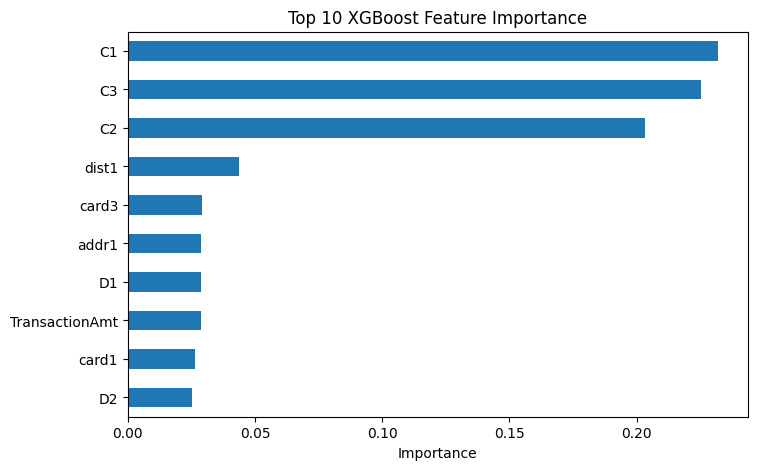

In [102]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()


In [103]:
svm = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train, y_train)

svm_prob = svm.predict_proba(X_test)[:, 1]

svm_pred = (svm_prob >= 0.50).astype(int)

print("\n" + "=" * 50)
print("SVM BASELINE RESULTS")
print("=" * 50)

print(classification_report(
    y_test,
    svm_pred,
    zero_division=0
))

print("ROC-AUC:",
      round(roc_auc_score(y_test, svm_prob), 4))

print("PR-AUC:",
      round(average_precision_score(y_test, svm_prob), 4))


SVM BASELINE RESULTS
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1746
           1       0.00      0.00      0.00        54

    accuracy                           0.97      1800
   macro avg       0.48      0.50      0.49      1800
weighted avg       0.94      0.97      0.96      1800

ROC-AUC: 0.5452
PR-AUC: 0.0648


In [104]:

results = pd.DataFrame({
    "Model": ["XGBoost", "SVM"],
    "Precision": [
        precision_score(y_test, xgb_pred, zero_division=0),
        precision_score(y_test, svm_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, xgb_pred, zero_division=0),
        recall_score(y_test, svm_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, xgb_pred, zero_division=0),
        f1_score(y_test, svm_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, svm_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, xgb_prob),
        average_precision_score(y_test, svm_prob)
    ]
})

print("\n" + "=" * 50)
print("FINAL MODEL COMPARISON")
print("=" * 50)

print(results.round(4).to_string(index=False))




FINAL MODEL COMPARISON
  Model  Precision  Recall     F1  ROC-AUC  PR-AUC
XGBoost     0.0399     0.5 0.0739   0.5798  0.0419
    SVM     0.0000     0.0 0.0000   0.5452  0.0648


In [105]:
print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))


XGBoost Confusion Matrix:
[[1096  650]
 [  27   27]]
